## CLUSTERING ANALYSIS

#### 1. Data Preprocessing

Load Dataset

In [2]:
import pandas as pd

df = pd.read_csv(r"C:\Users\suraj\OneDrive\Desktop\data sets\EastWestAirlines.csv")
df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


Handle Missing Values

In [3]:
df = df.fillna(df.mean(numeric_only=True))

Remove Outliers

In [4]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

df = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

Feature Scaling

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.select_dtypes(include=['number']))

#### 2. Exploratory Data Analysis

Histograms

array([[<Axes: title={'center': 'ID#'}>,
        <Axes: title={'center': 'Balance'}>,
        <Axes: title={'center': 'Qual_miles'}>],
       [<Axes: title={'center': 'cc1_miles'}>,
        <Axes: title={'center': 'cc2_miles'}>,
        <Axes: title={'center': 'cc3_miles'}>],
       [<Axes: title={'center': 'Bonus_miles'}>,
        <Axes: title={'center': 'Bonus_trans'}>,
        <Axes: title={'center': 'Flight_miles_12mo'}>],
       [<Axes: title={'center': 'Flight_trans_12'}>,
        <Axes: title={'center': 'Days_since_enroll'}>,
        <Axes: title={'center': 'Award?'}>]], dtype=object)

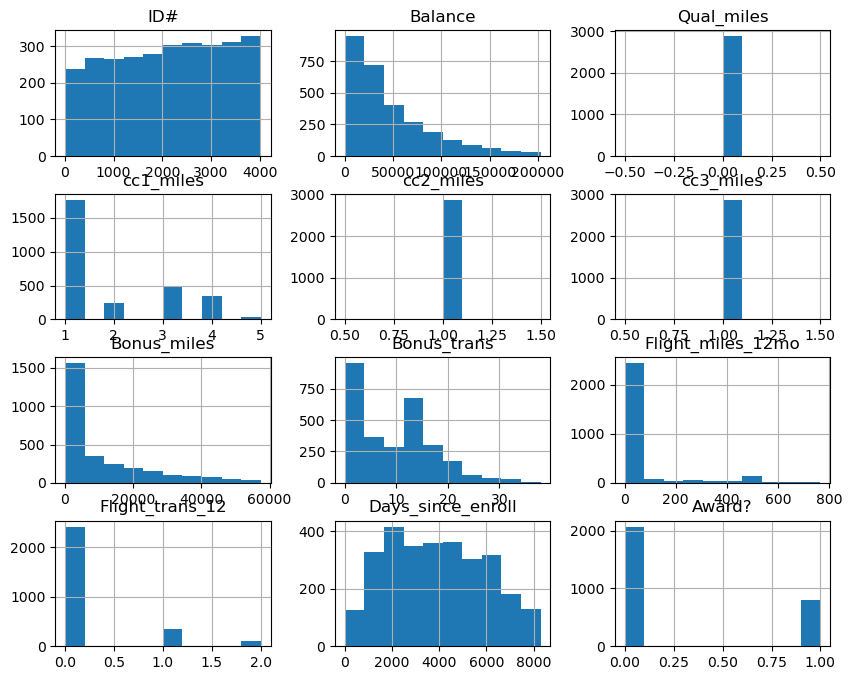

In [6]:
df.hist(figsize=(10,8))

Correlation Heatmap

Text(0.5, 1.0, 'Correlation Matrix')

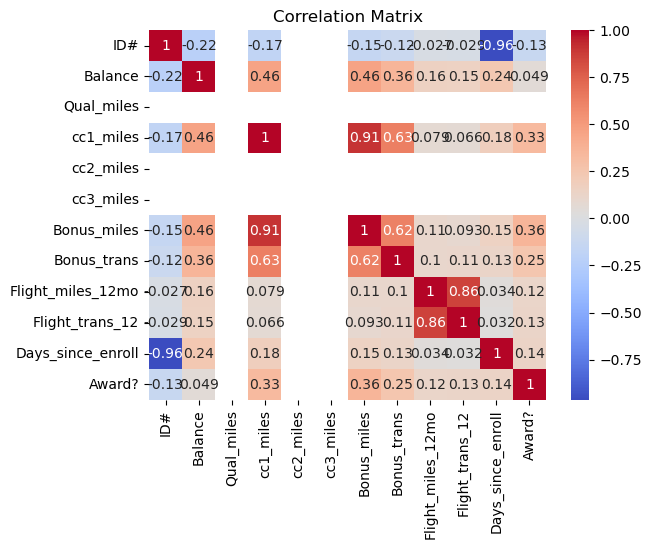

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")

#### 3. K-Means Clustering

Elbow Method

Text(0.5, 1.0, 'Elbow Method')

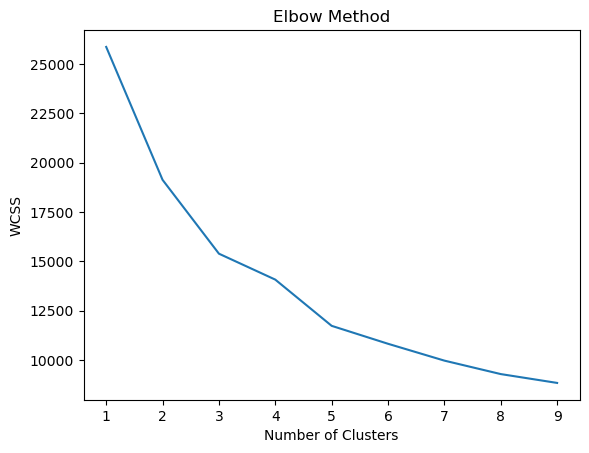

In [8]:
from sklearn.cluster import KMeans

wcss = []
for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,10), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

Apply K-Means

In [9]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

#### 4. Hierarchical Clustering

Dendrogram

Text(0.5, 1.0, 'Dendrogram')

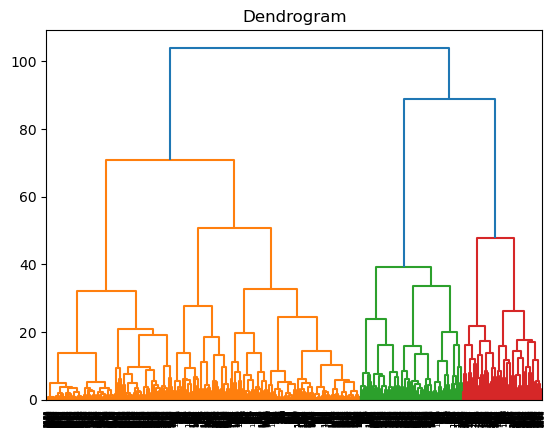

In [10]:
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(X_scaled, method='ward')

dendrogram(linked)
plt.title("Dendrogram")

Apply Hierarchical

In [11]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=3)
hc_labels = hc.fit_predict(X_scaled)

#### 5. DBSCAN Clustering

In [12]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)

#### 6. Visualization

Text(0.5, 1.0, 'DBSCAN Clusters')

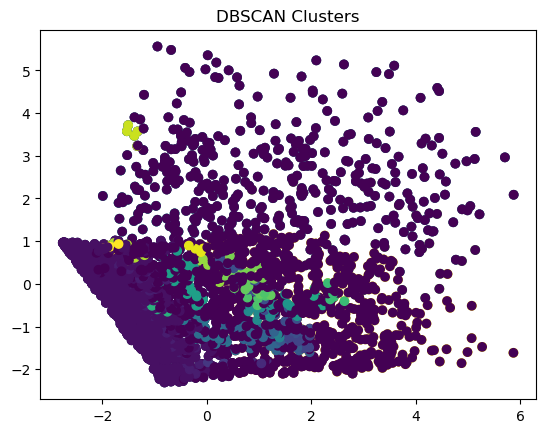

In [13]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
#Plot K-Means
plt.scatter(X_pca[:,0], X_pca[:,1], c=kmeans_labels)
plt.title("K-Means Clusters")
#Plot Hierarchical
plt.scatter(X_pca[:,0], X_pca[:,1], c=hc_labels)
plt.title("Hierarchical Clusters")
#Plot DBSCAN
plt.scatter(X_pca[:,0], X_pca[:,1], c=db_labels)
plt.title("DBSCAN Clusters")

### 7. Evaluation Metrics

In [14]:
from sklearn.metrics import silhouette_score

print("KMeans Silhouette:", silhouette_score(X_scaled, kmeans_labels))
print("Hierarchical Silhouette:", silhouette_score(X_scaled, hc_labels))

# DBSCAN only if more than 1 cluster
if len(set(db_labels)) > 1:
    print("DBSCAN Silhouette:", silhouette_score(X_scaled, db_labels))

KMeans Silhouette: 0.30830264215957265
Hierarchical Silhouette: 0.27936255076255034
DBSCAN Silhouette: -0.33225832280910966


#### 8. Cluster Analysis & Interpretation (Write This)
Sample Insights:
K-Means formed well-separated clusters
Hierarchical clustering shows clear grouping in dendrogram
DBSCAN identifies noise points (-1 label)

 #### 9. Comparison
Algorithm	Strength	Weakness
K-Means	Fast, simple	Needs K
Hierarchical	No need K initially	Slow
DBSCAN	Detects noise	Sensitive to eps

#### 10. Conclusion 
K-Means provides efficient clustering for well-separated data, hierarchical clustering helps visualize relationships through dendrograms, and DBSCAN is useful for detecting noise and irregular cluster shapes. The choice of algorithm depends on dataset characteristics and clustering objectives.